# Financial Tweet Sentiment Analysis — Data Preprocessing

Ce notebook prépare les données pour les modèles de Deep Learning.

Objectifs :
- Charger les tweets financiers
- Nettoyer le texte
- Encoder les labels
- Vérifier la distribution des classes
- Diviser les données en Train / Validation / Test
- Sauvegarder les datasets préprocessés

**Imports & Configuration**

In [18]:
import os, json, random
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import AutoTokenizer

# ── Seeds reproductibilité ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Chemins ─────────────────────────────────────────────────────────────────
RAW_FILE   = 'data/processed/stock_tweets_cleaned_capped_sentiment_responses_minimal.csv'
OUT_DIR    = Path('data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR    = Path('results')
RES_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparamètres ─────────────────────────────────────────────────────────
MAX_LENGTH   = 128        # justifié : tweets ≤ 280 chars → ~60 tokens en moyenne
TOKENIZER_ID = 'ProsusAI/finbert'   # utilisé pour les 3 modèles transformers
SPLIT_RATIOS = (0.70, 0.15, 0.15)   # train / val / test

print('OUT_DIR:', OUT_DIR)

OUT_DIR: data\processed


**Chargement des données labellisées**

In [19]:
df = pd.read_csv(RAW_FILE, encoding='utf-8-sig')

# Garder les colonnes utiles
KEEP = ['Tweet_clean', 'Tweet_original', 'Stock Name', 'Date', 'sentiment', 'sentiment_score']
df = df[[c for c in KEEP if c in df.columns]].copy()


# Convertion sentiment_score (+1/0/-1) en label entier (0/1/2)
# Convention : 0=négatif, 1=neutre, 2=positif
SCORE_TO_LABEL = {-1: 0, 0: 1, 1: 2}
LABEL_TO_NAME  = {0: 'négatif', 1: 'neutre', 2: 'positif'}
df['label'] = df['sentiment_score'].map(SCORE_TO_LABEL).astype(int)

df = df.reset_index(drop=False).rename(columns={'index': 'original_index'})
print(f'Dataset final : {len(df)} exemples')
df.head(3)

Dataset final : 42252 exemples


,original_index,Tweet_clean,Tweet_original,Stock Name,Date,sentiment,sentiment_score,label
0,0,"Sell AMOUNT_41,000 worth of TICKER_AAPL for 1,...","Sell $41,000 worth of $AAPL for 1,000 more sha...",AAPL,2021-11-02 00:27:27+00:00,neutral,0,1
1,1,"TICKER_AAPL CFO, Luca Maestri, filed Form 144 ...","$AAPL CFO, Luca Maestri, filed Form 144 paperw...",AAPL,2022-08-18 20:34:48+00:00,neutral,0,1
2,2,TICKER_AAPL they re gonna say the news is fake...,$AAPL they’re gonna say the news is fake and t...,AAPL,2022-09-28 13:09:01+00:00,negative,-1,0


**Distribution des classes**

Distribution des classes :
  négatif (0) : 7980 (18.9%)
  neutre (1) : 18468 (43.7%)
  positif (2) : 15804 (37.4%)


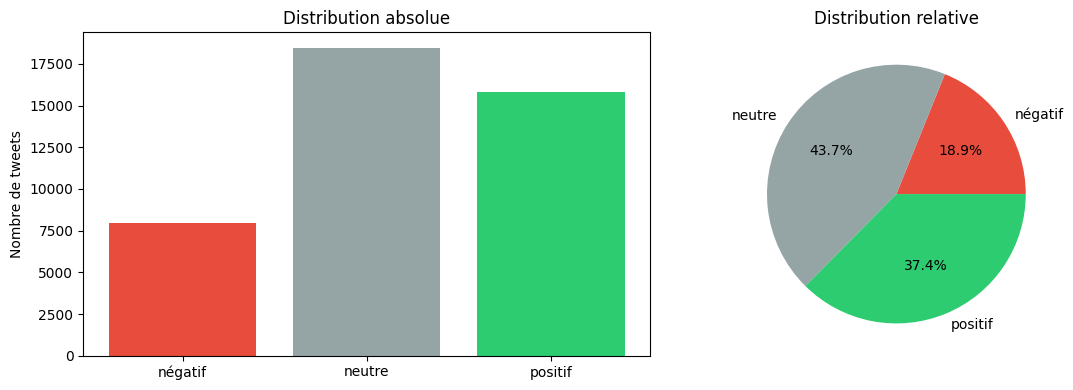


Ratio max/min : 2.31
Déséquilibre modéré : class_weight + surveiller F1 par classe


In [20]:
counts = df['label'].value_counts().sort_index()
print('Distribution des classes :')
for lbl, cnt in counts.items():
    print(f'  {LABEL_TO_NAME[lbl]} ({lbl}) : {cnt} ({100*cnt/len(df):.1f}%)')
    

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([LABEL_TO_NAME[i] for i in counts.index], counts.values,
            color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Distribution absolue')
axes[0].set_ylabel('Nombre de tweets')

axes[1].pie(counts.values, labels=[LABEL_TO_NAME[i] for i in counts.index],
            autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('Distribution relative')
plt.tight_layout()
plt.savefig(RES_DIR / 'class_distribution.png', dpi=150)
plt.show()

# ── Calcul du ratio de déséquilibre ─────────────────────────────────────────
imbalance_ratio = counts.max() / counts.min()
print(f'\nRatio max/min : {imbalance_ratio:.2f}')

if imbalance_ratio < 2.0:
    strategy = 'class_weight'
    print('Déséquilibre léger : stratégie class_weight (sklearn + PyTorch)')
elif imbalance_ratio < 5.0:
    strategy = 'class_weight'
    print('Déséquilibre modéré : class_weight + surveiller F1 par classe')
else:
    strategy = 'focal_loss'
    print('Fort déséquilibre : Focal Loss recommandée')


In [21]:
# ── Calcul des poids de pénalisation selon la classe et sa répartition ─────────────────────────────────────────────────
labels_array = df['label'].values
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=labels_array
)
class_weights_dict = {int(i): float(w) for i, w in enumerate(class_weights_array)}
print('\nClass weights :', class_weights_dict)

with open(RES_DIR / 'class_weights.json', 'w') as f:
    json.dump({
        'weights': class_weights_dict,
        'strategy': strategy,
        'imbalance_ratio': float(imbalance_ratio),
        'label_mapping': SCORE_TO_LABEL
    }, f, indent=2)
print('Sauvegardé : results/class_weights.json')


Class weights : {0: 1.7649122807017543, 1: 0.7626164175871778, 2: 0.8911667932169071}
Sauvegardé : results/class_weights.json


**Split Train / Validation / Test (stratifié)**

In [22]:
# ── Utilisation de la stratification ──────────────────────────────────────────────────────
# un split aléatoire simple pourrait créer val/test avec 0 exemples de la classe
# minoritaire. Le split stratifié garantit les mêmes proportions dans chaque split.

TRAIN_RATIO = SPLIT_RATIOS[0]  # 0.70
VAL_RATIO   = SPLIT_RATIOS[1]  # 0.15
TEST_RATIO  = SPLIT_RATIOS[2]  # 0.15

# Étape 1 : train vs (val+test)
df_train, df_temp = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=SEED
)

# Étape 2 : val vs test (50/50 du temp)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5,
    stratify=df_temp['label'], random_state=SEED
)

print(f'Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')

# Vérifier la distribution dans chaque split
for name, subset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = subset['label'].value_counts(normalize=True).sort_index()
    print(f'{name} → ' + ' | '.join(f'{LABEL_TO_NAME[i]}: {v:.1%}' for i, v in dist.items()))



Train : 29576 | Val : 6338 | Test : 6338
Train → négatif: 18.9% | neutre: 43.7% | positif: 37.4%
Val → négatif: 18.9% | neutre: 43.7% | positif: 37.4%
Test → négatif: 18.9% | neutre: 43.7% | positif: 37.4%


**Sauvegarde des CSV**

In [24]:
COLS_OUT = ['original_index', 'Tweet_clean', 'label', 'Stock Name', 'Date']
COLS_OUT = [c for c in COLS_OUT if c in df_train.columns]

df_train[COLS_OUT].to_csv(OUT_DIR / 'train.csv', index=False)
df_val[COLS_OUT].to_csv(OUT_DIR  / 'val.csv',   index=False)
df_test[COLS_OUT].to_csv(OUT_DIR / 'test.csv',  index=False)

print('Sauvegardés : train.csv / val.csv / test.csv')

Sauvegardés : train.csv / val.csv / test.csv


**Construction de la structure du graphe (pour Modèle 3 — GAT)**

In [23]:
# ── Construction de la structure du graphe (pour Modèle C — GAT) ─────────────
# Logique : deux tweets sont connectés s'ils parlent du même stock
# le même jour → ils partagent un contexte de marché commun


def build_graph_edges(subset_df):
    """
    Construit les arêtes du graphe pour un split donné.
    
    Nœuds  : chaque tweet (indexé 0..N-1 dans le split)
    Arêtes : paires de tweets avec même Stock Name + même Date (jour)
    
    Retourne edge_index de shape (2, nb_arêtes) — format PyG standard
    """
    df_reset = subset_df.reset_index(drop=True).copy()
    df_reset['Date_day'] = pd.to_datetime(df_reset['Date']).dt.date

    edges_src, edges_dst = [], []

    # Grouper par (stock, jour)
    groups = df_reset.groupby(['Stock Name', 'Date_day'])

    for (stock, day), group in groups:
        indices = group.index.tolist()
        if len(indices) < 2:
            continue   # un seul tweet ce jour → pas d'arête
        # Créer toutes les paires 
        for i, j in itertools.combinations(indices, 2):
            edges_src.append(i)
            edges_dst.append(j)
            edges_src.append(j)  # non-orienté, on ajoute les deux sens
            edges_dst.append(i)

    edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)
    return edge_index

for split_name, subset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    edge_index = build_graph_edges(subset)
    torch.save(edge_index, OUT_DIR / f'{split_name}_edge_index.pt')
    n_nodes = len(subset)
    n_edges = edge_index.shape[1] // 2   # diviser par 2 car non-orienté
    print(f'{split_name} — nœuds: {n_nodes} | arêtes: {n_edges}')

train — nœuds: 29576 | arêtes: 248598
val — nœuds: 6338 | arêtes: 11791
test — nœuds: 6338 | arêtes: 10760


**Tokenisation & Sauvegarde des encodings (.pt) pour eviter de recalculer**

In [25]:
# ── Pourquoi max_length=128 ? ─────────────────────────────────────────────────
# Les tweets font max 280 caractères ≈ 50-70 tokens en moyenne.
# max_length=128 couvre >99% des tweets avec un padding raisonnable.
# max_length=512 (défaut BERT) multiplierait par 4 la mémoire GPU sans gain.

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

# ── Ajouter les tokens spéciaux TICKER et AMOUNT ─────────────────────────────
# Ces tokens issus du preprocessing doivent être reconnus par le tokenizer.
special_tokens = [f'TICKER_{s}' for s in [
    'AAPL','MSFT','GOOGL','AMZN','TSLA','META','NVDA','BRK','JPM',
    'JNJ','V','PG','UNH','HD','MA','PYPL','BAC','DIS','ADBE','NFLX',
    'CMCSA','XOM','VZ','INTC','T','CSCO','PFE'
]] + ['AMOUNT_']

tokenizer.add_tokens(special_tokens, special_tokens=False)

def tokenize_split(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
        return_attention_mask=True
    )

for split_name, subset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    enc = tokenize_split(subset['Tweet_clean'], tokenizer)
    out = {
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         torch.tensor(subset['label'].values, dtype=torch.long),
    }
    torch.save(out, OUT_DIR / f'{split_name}_encodings.pt')
    print(f' {split_name}_encodings.pt — input_ids shape: {out["input_ids"].shape}')
    #.pt car consommable facilement avec pytorch.

# Vérification dimensions
enc_check = torch.load(OUT_DIR / 'train_encodings.pt')
N, L = enc_check['input_ids'].shape
assert L == MAX_LENGTH, f'Longueur attendue {MAX_LENGTH}, obtenu {L}'
print(f'\n Dimensions encodings : {N} × {L}')

 train_encodings.pt — input_ids shape: torch.Size([29576, 128])
 val_encodings.pt — input_ids shape: torch.Size([6338, 128])
 test_encodings.pt — input_ids shape: torch.Size([6338, 128])

 Dimensions encodings : 29576 × 128


C:\Users\cherb\AppData\Local\Temp\ipykernel_636\807230581.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  enc_check = torch.load(OUT_DIR / 'train_encodings.pt')


**Checklist finale**

In [26]:
print('=' * 60)
print('CHECKLIST FINALE')
print('=' * 60)

checks = []

# 1. Aucun NaN dans les splits
for fname in ['train.csv', 'val.csv', 'test.csv']:
    tmp = pd.read_csv(OUT_DIR / fname)
    nan_count = tmp.isnull().sum().sum()
    checks.append((f'Aucun NaN — {fname}', nan_count == 0))

# 2. Distribution cohérente
train_dist = pd.read_csv(OUT_DIR / 'train.csv')['label'].value_counts(normalize=True)
test_dist  = pd.read_csv(OUT_DIR / 'test.csv')['label'].value_counts(normalize=True)
max_drift  = (train_dist - test_dist).abs().max()
checks.append(('Distribution train/test cohérente (drift < 3%)', max_drift < 0.03))

# 3. Pas de data leakage
t1 = set(pd.read_csv(OUT_DIR / 'train.csv')['original_index'])
t2 = set(pd.read_csv(OUT_DIR / 'val.csv')['original_index'])
t3 = set(pd.read_csv(OUT_DIR / 'test.csv')['original_index'])
checks.append(('Aucun data leakage', len(t1&t2)==0 and len(t1&t3)==0 and len(t2&t3)==0))

for split_name in ['train', 'val', 'test']:
    edge_path = OUT_DIR / f'{split_name}_edge_index.pt'
    checks.append((
        f'edge_index présent — {split_name}',
        edge_path.exists()
    ))

# Vérifier que Stock Name et Date sont bien dans les CSV
train_df = pd.read_csv(OUT_DIR / 'train.csv')
checks.append(('Stock Name présent', 'Stock Name' in train_df.columns))
checks.append(('Date présent', 'Date' in train_df.columns))

# 5. Encodings dimensions
enc = torch.load(OUT_DIR / 'train_encodings.pt')
checks.append((f'Encodings shape N×{MAX_LENGTH}', enc["input_ids"].shape[1] == MAX_LENGTH))

# 6. class_weights.json
checks.append(('class_weights.json sauvegardé', (RES_DIR / 'class_weights.json').exists()))

for label, ok in checks:
    status = 'OK' if ok else 'NOT OK'
    print(f'  {status} {label}')

all_ok = all(ok for _, ok in checks)
print('\n' + ('PREPROCESSING TERMINÉ — Prêt pour la modélisation' if all_ok else '❌ ERREURS DÉTECTÉES — Corriger avant de continuer'))

CHECKLIST FINALE


C:\Users\cherb\AppData\Local\Temp\ipykernel_636\2401059166.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  enc = torch.load(OUT_DIR / 'train_encodings.pt')


  OK Aucun NaN — train.csv
  OK Aucun NaN — val.csv
  OK Aucun NaN — test.csv
  OK Distribution train/test cohérente (drift < 3%)
  OK Aucun data leakage
  OK edge_index présent — train
  OK edge_index présent — val
  OK edge_index présent — test
  OK Stock Name présent
  OK Date présent
  OK Encodings shape N×128
  OK class_weights.json sauvegardé

PREPROCESSING TERMINÉ — Prêt pour la modélisation
